### Using the API to guess density for a composition given a Composition + optionally XRD


### 1. Get the container up and running (GPU required)

Read the README.md/API section for setup




### 2. Testing on known Structures (from MP-20 test set)

I just downloaded CIFs from the original repo to show how we can go from a zipped folder of CIFs to the format expected by CrystaLLM-pi (this version). Testing on https://zenodo.org/records/10642388/files/mp_20_test_orig.tar.gz, I downloaded and put in in /app/data/data/mp_20_test_orig.tar.gz

You can look at the logs in /app/outputs/api_job_logs/
Some requests can take a bit of time to complete

> *Here we look at the case where we make composition prompts from known crystal structures (a set of 9,500~ structures), predict densities with CrystaLLM-pi, and compare to the known density*

a. Convert to dataframe

```bash
curl -X POST "http://localhost:8000/preprocessing/cifs-zip-to-parquet" \
  -H "Content-Type: application/json" \
  -d '{
  "input_tarballs": ["/app/data/mp_20_test_orig.tar.gz"],
  "output_parquet": "/app/data/mp_20_test.parquet",
  "database_name": "mp-20",
  "num_workers": "16"
  }'
```

b. add XRD conditioning column (theoretical XRD calculated from pymatgen, 
not required but for demonstration)

```bash
curl -X POST "http://localhost:8000/preprocessing/calc-theor-xrd" \
  -H "Content-Type: application/json" \
  -d '{
  "input_parquet": "/app/data/mp_20_test.parquet",
  "output_parquet": "/app/data/mp_20_test_xrd.parquet",
  "num_workers": "16"
  }'
```

c. we make a set of prompts from the test set. Prompts are set to level_2 which means we do prompts from composition (space group not specified).

```bash
curl -X POST "http://localhost:8000/generate/make-prompts" \
  -H "Content-Type: application/json" \
  -d '{
  "input_parquet": "/app/data/mp_20_test_xrd.parquet",
  "output_parquet": "/app/data/mp_20_test_xrd_prompts.parquet",
  "level": "level_2",
  "condition_columns": "condition_vector",
  "automatic": "true"
  }'
```


In [21]:
# I'm going to chop the df to 1K materials for demonstration purposes. You can remove this line to process all materials if youd like.

import __init__
import pandas as pd

df = pd.read_parquet("data/mp_20_test_xrd_prompts.parquet")

df = df.head(1000)

df.to_parquet("data/mp_20_test_xrd_prompts_1K.parquet")

d1. We generate a candidate for each CIF. Here we do it given an XRD. 

```bash
curl -X POST "http://localhost:8000/generate/direct" \
  -H "Content-Type: application/json" \
  -d '{
    "hf_model_path": "c-bone/CrystaLLM-pi_Mattergen-XRD",
    "input_parquet": "/app/data/mp_20_test_xrd_prompts_1K.parquet",
    "num_return_sequences": 5,
    "max_return_attempts": 2,
    "target_valid_cifs": 1,
    "scoring_mode": "LOGP",
    "temperature": 0.75,
    "output_parquet": "/app/data/mp_20_test_xrd_gens_logp_1K.parquet"
  }'
```

> We are doing a batch of 5 generation attempts per compound: num_return_sequences
> 
> With 2 tries if the first batch didn't manage to generate a valid CIF: max_return_attempst.
>  
> Scoring mode LOGP means we rank the outputs by perplexity (lower means model is more 'confident' in this answer), and return the output generation with the best score (top N returned set by target_valid_cifs).
>
> I choose a sampling temperature of 0.75 (slightly conservative) because I had done some ablations for the paper and it worked well for this type of setting. (good blog for understanding sampling in LLMs: https://huggingface.co/blog/how-to-generate)
>
> This step takes about 0.75GB on my each of my 2 GPUs and ~ 3 hours. Its about 10.8 seconds per sample. Long because we generate 5, calculate the model confidence scores and take best ranked.

d2. If speed is what we want, and we dont care if the outputs are fully chemically valid and we just want to take the 1st generation attempt as is we can do it this way.

```bash
curl -X POST "http://localhost:8000/generate/direct" \
  -H "Content-Type: application/json" \
  -d '{
    "hf_model_path": "c-bone/CrystaLLM-pi_Mattergen-XRD",
    "input_parquet": "/app/data/mp_20_test_xrd_prompts_1K.parquet",
    "num_return_sequences": 1,
    "temperature": 0.75,
    "output_parquet": "/app/data/mp_20_test_xrd_gens_1K.parquet"
  }'
```

e1. generate a candidate for each composition, no XRD (can just use same input but load the base model, which doesnt take any XRD conditions and itll ignore the XRD column)

```bash
curl -X POST "http://localhost:8000/generate/direct" \
  -H "Content-Type: application/json" \
  -d '{
    "hf_model_path": "c-bone/CrystaLLM-pi_base",
    "input_parquet": "/app/data/mp_20_test_xrd_prompts_1K.parquet",
    "num_return_sequences": 5,
    "max_return_attempts": 2,
    "target_valid_cifs": 1,
    "scoring_mode": "LOGP",
    "temperature": 0.75,
    "output_parquet": "/app/data/mp_20_test_gens_logp_1K.parquet"
  }'
```

e2. generate a candidate for each composition, no XRD (can just use same input but load the base model, which doesnt take any XRD conditions and itll ignore the XRD column)

```bash
curl -X POST "http://localhost:8000/generate/direct" \
  -H "Content-Type: application/json" \
  -d '{
    "hf_model_path": "c-bone/CrystaLLM-pi_base",
    "input_parquet": "/app/data/mp_20_test_xrd_prompts_1K.parquet",
    "num_return_sequences": 1,
    "temperature": 0.75,
    "output_parquet": "/app/data/mp_20_test_gens_1K.parquet"
  }'
```

f. extract densities for each, and compare true densities vs predicted for XRD vs Base models, and no ranked outputs vs ranked outputs

I just use pymatgen to extract density but any method can be used

In [1]:
%matplotlib inline

In [3]:
import __init__
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Tuple, Optional
from scipy.stats import pearsonr

from _utils import get_density

# Global constants for paths to minimize arguments
TRUE_DATA_PATH = "data/mp_20_test_xrd_prompts_1K.parquet"
GEN_DATA_PATHS = {
    "base_none": "data/mp_20_test_gens_1K.parquet",
    "base_logp": "data/mp_20_test_gens_logp_1K.parquet",
    "xrd_none": "data/mp_20_test_xrd_gens_1K.parquet",
    "xrd_logp": "data/mp_20_test_xrd_gens_logp_1K.parquet",
}

def calculate_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Tuple[float, float, float]:
    """Calculate MAE, standard deviation of absolute errors, and Pearson's r."""
    abs_errors = np.abs(y_true - y_pred)
    mae = float(np.mean(abs_errors))
    std_dev = float(np.std(abs_errors))
    r_val, _ = pearsonr(y_true, y_pred)

    return mae, std_dev, r_val

def load_and_compute_densities(path: str) -> pd.DataFrame:
    """Load parquet file and compute densities for all valid CIFs."""
    df = pd.read_parquet(path)
    cif_col = "CIF" if "CIF" in df.columns else "Generated CIF"
            
    df["density_g/cm3"] = df[cif_col].apply(get_density)
    return df

Navigated to package root


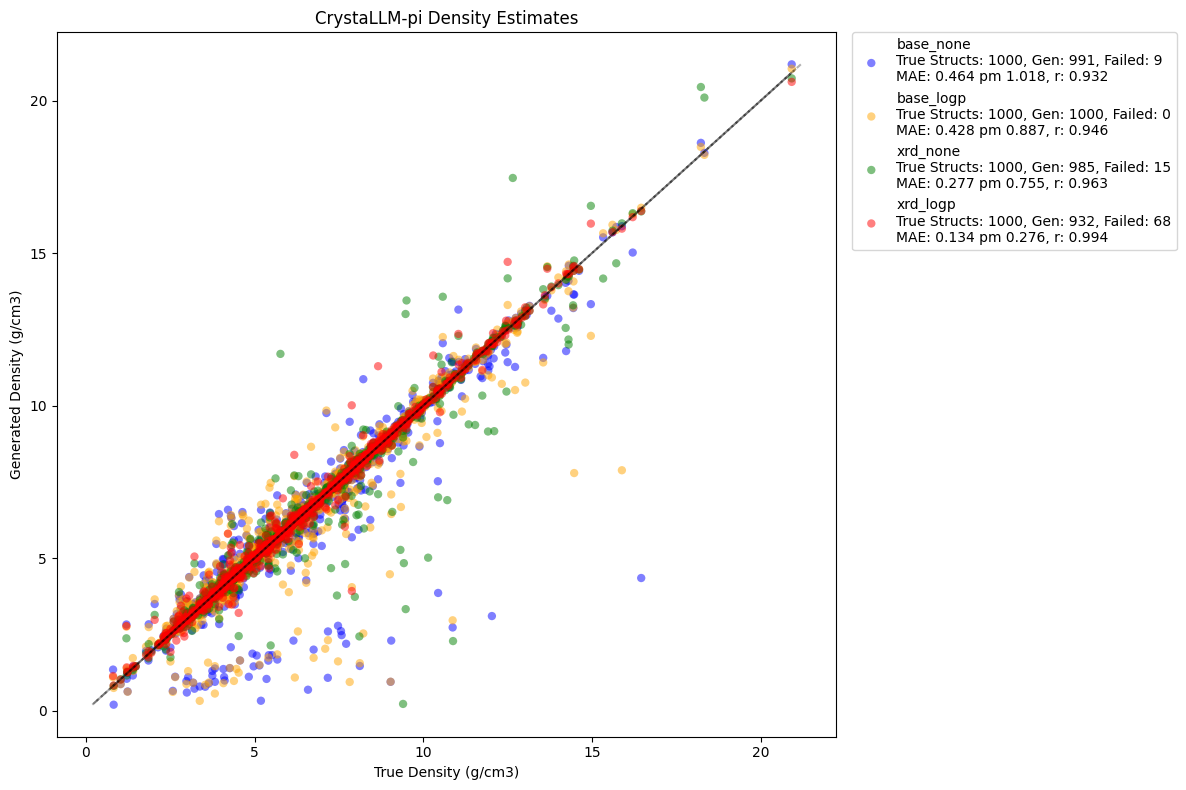

In [5]:
df_true = load_and_compute_densities(TRUE_DATA_PATH)
total_true = len(df_true)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['blue', 'orange', 'green', 'red']

for idx, (label, path) in enumerate(GEN_DATA_PATHS.items()):
    df_gen = load_and_compute_densities(path)
    
    # Merge datasets on Material ID
    merged = pd.merge(df_true, df_gen, on="Material ID", suffixes=("_true", "_gen"))
    
    # Filter down to pairs where both CIFs yielded a valid density
    valid_mask = merged["density_g/cm3_true"].notna() & merged["density_g/cm3_gen"].notna()
    valid_data = merged[valid_mask]
    
    # Calculate invalid_count: total target materials minus the ones successfully generated and parsed
    invalid_count = total_true - len(valid_data)
        
    y_true = valid_data["density_g/cm3_true"].values
    y_pred = valid_data["density_g/cm3_gen"].values
    
    mae, std_dev, r_val = calculate_metrics(y_true, y_pred)
    
    # Format a comprehensive legend entry
    legend_label = (
        f"{label}\n"
        f"True Structs: {total_true}, Gen: {len(valid_data)}, Failed: {invalid_count}\n"
        f"MAE: {mae:.3f} pm {std_dev:.3f}, r: {r_val:.3f}"
    )
    
    ax.scatter(y_true, y_pred, alpha=0.5, color=colors[idx], label=legend_label, edgecolors='none')
    
    # Track limits to draw the perfect agreement line correctly
    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))

    ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.3)

ax.set_xlabel("True Density (g/cm3)")
ax.set_ylabel("Generated Density (g/cm3)")
ax.set_title("CrystaLLM-pi Density Estimates")

# Place legend outside the plot area so it doesn't obscure the data points
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

> As expected, if we provide XRD information, the guesses are more accurate. If on top of that we do return the most confidently predicted structure out of 5 gens it improved further, but with a 9 fold~ increase in generation time (10.8 seconds/struct vs 1.2 sec/struc).

> Also for the scoring method, since we ensure the outputs are chemically valid before scoring them, we have a higher number of 'failed' generation attempts as the these tests are more stringent. With a higher number of generation attempts we can potentially fix this though with more resources

### 3. Testing on new structures

What you need to gather:
- Composition of a material (Reduced Formula), or if Z is known even better but not necessary
- Optional: XRD pattern
  - Will need to specify what primary radiation wavelength is for the XRD profile if it is not Cu-Kalpha (1.54056 A)
  - If there are redundant peaks due to additional radiation sources, these need to be removed as well (eg. if sample irradiated with K-alpha1 and K-alpha2, remove K-alpha2 peaks)
  - Data should be in a .csv, .txt, .xy, or .dat file

> **Warning**: as of yet, model only accepts ordered materials with integer stoichiometries and full occupancy etc. You can try to multiply the cell composition to achieve integer stoichiometries in the case we have partial occupancy. Doping and Defect are out of the scope of the training data as of now though.
>
> **For XRD**: if providing an XRD pattern, you must provide pre-picked peaks in a `.csv`, `.xy`, `.txt`, or `.dat` file. The internal preprocessing engine will automatically convert your data to the expected CuKa wavelength (if you provide your instrument's wavelength via `xrd_wavelength`), filter valid ranges, normalize intensities, and select the top peaks for model conditioning.

a. With these arguments, the script will search through Z=1,2,3,4 for a given reduced formula. If you choose the confidence score it returns the most confident structure prediction out of all Z's, but if you choose no scoring it just returns the first output structure which is chemcially valid. (top N structures returned set by `target_valid_cifs` arg.)

*As an example I'll try to predict the structure of rutile polymorph of TiO2, but these API requests can be changed for whatever inputs*, you can check the Readme for more examples (API section)

a1. If we do reduced_formula_search for XRD model + confidence score 

```bash
curl -X POST "http://localhost:8000/generate/direct" \
  -H "Content-Type: application/json" \
  -d '{
    "hf_model_path": "c-bone/CrystaLLM-pi_Mattergen-XRD",
    "reduced_formula_list": "TiO2",
    "search_zs": true,
    "xrd_files": ["/app/tests/fixtures/test_rutile_processed.csv"],
    "scoring_mode": "LOGP",
    "target_valid_cifs": 1,
    "num_return_sequences": 5,
    "max_return_attempts": 2,
    "temperature": 1.0,
    "output_parquet": "/app/data/TiO2_XRD_pred.parquet"
  }'
```

> note: you can also do multiple reduced formulas if you have multiple formula/xrd pairs.
> 
> "reduced_formula_list": "TiO2,SiO2,...,GaAs"
> 
> "xrd_files": ["app/tests/fixtures/test_rutile_processed.csv", "<path2>", "...", "<path3>"]

a2. If we do reduced_formula_search for base model + No confidence score. We output first valid structure guess for TiO2 and SiO2.

```bash
curl -X POST "http://localhost:8000/generate/direct" \
  -H "Content-Type: application/json" \
  -d '{
    "hf_model_path": "c-bone/CrystaLLM-pi_base",
    "reduced_formula_list": "SiO2,TiO2",
    "search_zs": true,
    "num_return_sequences": 5,
    "max_return_attempts": 2,
    "target_valid_cifs": 1,
    "output_parquet": "/app/data/set_base_preds.parquet"
  }'
```

> Note: You can change the search space for the z_search algorithm by changing the DEFAULT_Z_LIST global constant in `_load_and_generate.py`

In [27]:
import __init__
import pandas as pd

df1 = pd.read_parquet("data/set_base_preds.parquet")
df2 = pd.read_parquet("data/TiO2_XRD_pred.parquet")

# # add a new density column to each df by applying the get_density function to the CIF column
from _utils import get_density

df1["density_g/cm3"] = df1["Generated CIF"].apply(get_density)
df2["density_g/cm3"] = df2["Generated CIF"].apply(get_density)

print(df1[["Material ID", "density_g/cm3"]].head())
print(df2[["Material ID", "density_g/cm3"]].head())

  Material ID  density_g/cm3
0   SiO2_Z1_1       0.860932
1   TiO2_Z1_2       1.018277
  Material ID  density_g/cm3
0   TiO2_Z2_2       4.186939
